# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：基于 Bi-LSTM 的中文游戏评论情感分类
- 姓    名：（请填写）
- 学    号：（请填写）
- 班    级：（请填写）
- 指导教师：（请填写）
- 提交日期：2026 年 6 月

## 二、摘要

随着移动游戏市场的快速发展，用户评论成为衡量游戏口碑与商业潜力的重要数据来源。本项目基于 TapTap 平台中文游戏评论数据集，构建情感分类模型，自动判断评论属于「满意」或「不满意」。

数据经 jieba 分词、词表编码与序列 padding 预处理后，采用 Embedding + 双向 LSTM + 注意力池化 + 全连接层的深度学习架构进行二分类。实验对比了 Baseline、Optimized（强正则）与 Balanced（折中）三组超参数配置。最终 Balanced 模型在测试集上取得 **76.33%** 准确率与 **76.18%** Macro F1，较 Baseline 提升约 3.2 个百分点，同时有效缓解了过拟合问题。结果表明，在保持模型容量与完整序列长度的前提下，适度引入注意力机制与正则化策略，能够在泛化性能与训练稳定性之间取得较好平衡。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

TapTap 是国内知名的手游社区，玩家会在平台上发表大量中文评论。人工分析评论情感成本高、效率低。通过深度学习自动识别评论情感倾向，可以帮助开发者快速了解玩家反馈、辅助运营决策，具有明确的应用价值。

本项目选取 TapTap 公开评论数据集，探索 Bi-LSTM 在中文短文本/长文本情感分类任务上的效果，属于自然语言处理中的**文本分类**问题。

### 3.2 问题描述

| 项目 | 说明 |
|------|------|
| **输入** | 一条中文游戏评论文本 |
| **输出** | 情感标签：0（不满意）或 1（满意） |
| **任务类型** | 二分类（Binary Classification） |
| **评价指标** | Accuracy、Macro F1、Precision、Recall |
| **预期目标** | 测试集 Macro F1 ≥ 70%，并控制过拟合 |

## 四、数据集说明与预处理

### 4.1 数据来源与规模

- **数据来源**：TapTap 手游评论公开数据集（约 300 款游戏）
- **标注规则**：评分低于 3 星（满分 5 星）记为 0（不满意），其余记为 1（满意）
- **字段说明**：`review` 为评论正文，`sentiment` 为情感标签
- **划分方式**：按标签分层划分，训练集 70% / 验证集 15% / 测试集 15%，随机种子 42

In [1]:
import json
from pathlib import Path

import jieba
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")

PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "data"


def load_split(name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / f"{name}.csv", encoding="utf-8-sig")
    df["review"] = df["review"].astype(str).str.strip()
    df["sentiment"] = df["sentiment"].astype(int)
    return df


train_df = load_split("train")
val_df = load_split("val")
test_df = load_split("test")
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

split_stats = pd.DataFrame(
    {
        "样本数": [len(train_df), len(val_df), len(test_df), len(all_df)],
        "不满意(0)": [
            (train_df["sentiment"] == 0).sum(),
            (val_df["sentiment"] == 0).sum(),
            (test_df["sentiment"] == 0).sum(),
            (all_df["sentiment"] == 0).sum(),
        ],
        "满意(1)": [
            (train_df["sentiment"] == 1).sum(),
            (val_df["sentiment"] == 1).sum(),
            (test_df["sentiment"] == 1).sum(),
            (all_df["sentiment"] == 1).sum(),
        ],
    },
    index=["训练集", "验证集", "测试集", "合计"],
)
split_stats["不满意占比"] = (split_stats["不满意(0)"] / split_stats["样本数"]).map(lambda x: f"{x:.1%}")
split_stats["满意占比"] = (split_stats["满意(1)"] / split_stats["样本数"]).map(lambda x: f"{x:.1%}")
display(split_stats)

,样本数,不满意(0),满意(1),不满意占比,满意占比
训练集,3421,1720,1701,50.3%,49.7%
验证集,732,368,364,50.3%,49.7%
测试集,735,370,365,50.3%,49.7%
合计,4888,2458,2430,50.3%,49.7%


### 4.2 数据可视化与分析

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\huyuhuy\AppData\Local\Temp\jieba.cache
Loading model cost 0.563 seconds.
Prefix dict has been built successfully.
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\3350482168.py:23: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\3350482168.py:23: UserWarning: Glyph 28385 (\N{CJK UNIFIED IDEOGRAPH-6EE1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\3350482168.py:23: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\3350482168.py:23: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\3350482168.py:23: UserWarning: Glyph 26

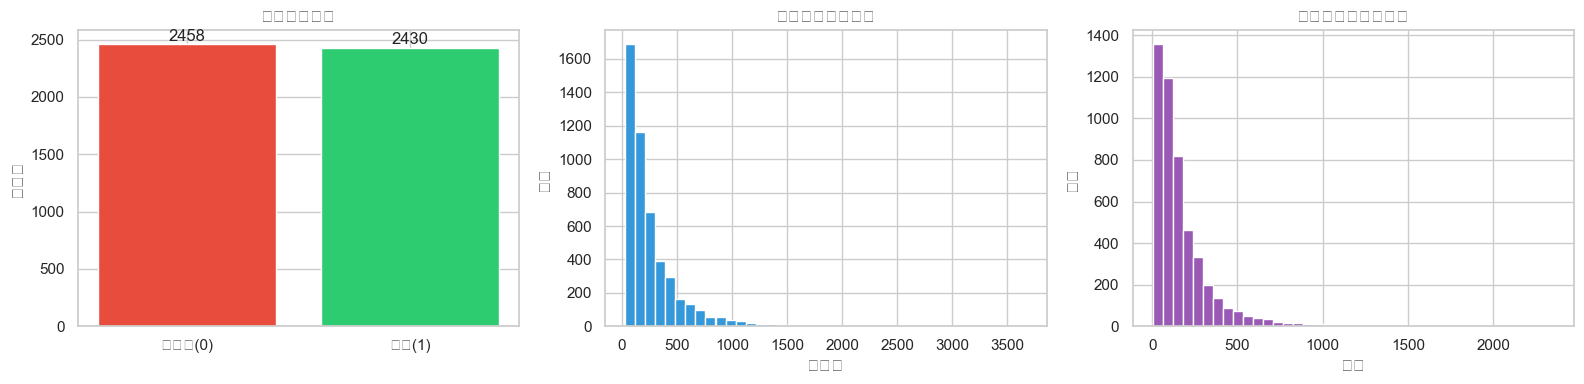

字符长度统计：


,count,mean,std,min,25%,50%,75%,max
char_len,4888.0,266.336129,294.735073,31.0,84.0,177.5,329.0,3675.0



分词长度统计：


,count,mean,std,min,25%,50%,75%,max
token_len,4888.0,169.643412,186.911874,2.0,54.0,114.0,212.0,2356.0



样本示例：

【不满意】实在想说半颗星都不想给 不但模仿我的世界，还有迷你世界，简直就是这个世界的人渣。

【满意】玩了勇者与魔王过后来玩的本作，虽然作为消遣的游戏已经很不错了，但依旧还是对本作有点期待过高。（此括弧有剧透：隐藏结局在本作没有了，而且全结局后，感觉个别坏结局稍微有些牵强，如首个泼水结局）总评分给4分（取平均分）：系统，和勇者魔王的系统是一...


In [2]:
all_df["char_len"] = all_df["review"].str.len()
all_df["token_len"] = all_df["review"].apply(lambda x: len([t for t in jieba.lcut(x) if t.strip()]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

label_counts = all_df["sentiment"].value_counts().sort_index()
axes[0].bar(["不满意(0)", "满意(1)"], label_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("整体标签分布")
axes[0].set_ylabel("样本数")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center")

axes[1].hist(all_df["char_len"], bins=40, color="#3498db", edgecolor="white")
axes[1].set_title("评论字符长度分布")
axes[1].set_xlabel("字符数")
axes[1].set_ylabel("频数")

axes[2].hist(all_df["token_len"], bins=40, color="#9b59b6", edgecolor="white")
axes[2].set_title("评论分词后词数分布")
axes[2].set_xlabel("词数")
axes[2].set_ylabel("频数")

plt.tight_layout()
plt.show()

print("字符长度统计：")
display(all_df["char_len"].describe().to_frame().T)
print("\n分词长度统计：")
display(all_df["token_len"].describe().to_frame().T)

print("\n样本示例：")
for label, name in [(0, "不满意"), (1, "满意")]:
    sample = all_df[all_df["sentiment"] == label].iloc[0]
    text = sample["review"][:120] + ("..." if len(sample["review"]) > 120 else "")
    print(f"\n【{name}】{text}")

**分析**：数据集两类样本比例接近 1:1，类别较为均衡；评论长度差异较大，部分评论超过 500 字，说明模型需要处理较长序列，也解释了 `max_len` 对性能的影响。

### 4.3 预处理流程

1. **清洗**：去除空评论，统一文本为字符串格式
2. **分词**：使用 jieba 对中文评论分词
3. **词表构建**：仅在训练集上统计词频，保留频次 ≥ `min_freq` 的词，其余映射为 `<UNK>`
4. **编码**：将词序列映射为整数 ID，截断至 `max_len`
5. **Padding**：同 batch 内序列 padding 至相同长度，使用 `pack_padded_sequence` 跳过 padding 参与 LSTM 计算
6. **划分**：分层随机划分 train / val / test = 7 : 1.5 : 1.5

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

除深度学习模型外，采用 **TF-IDF + 逻辑回归** 作为传统机器学习基线，用于对比深度模型的提升效果。

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.pipeline import Pipeline

tfidf_clf = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)
tfidf_clf.fit(train_df["review"], train_df["sentiment"])
tfidf_pred = tfidf_clf.predict(test_df["review"])

tfidf_acc = accuracy_score(test_df["sentiment"], tfidf_pred)
tfidf_f1 = f1_score(test_df["sentiment"], tfidf_pred, average="macro")

print(f"TF-IDF + 逻辑回归 | Test Acc = {tfidf_acc:.4f} | Test F1 = {tfidf_f1:.4f}")
print(classification_report(test_df["sentiment"], tfidf_pred, target_names=["不满意(0)", "满意(1)"]))

TF-IDF + 逻辑回归 | Test Acc = 0.6367 | Test F1 = 0.6284
              precision    recall  f1-score   support

      不满意(0)       0.61      0.78      0.68       370
       满意(1)       0.69      0.49      0.57       365

    accuracy                           0.64       735
   macro avg       0.65      0.64      0.63       735
weighted avg       0.65      0.64      0.63       735



### 5.2 最终模型架构

最终选用 **Bi-LSTM + Attention Pooling** 架构，整体流程如下：

```
输入评论 → jieba分词 → 词ID序列 → Embedding
    → 双向LSTM → 注意力加权池化 → Dropout → 全连接 → Softmax → 输出(0/1)
```

| 模块 | 参数说明 |
|------|----------|
| Embedding | 维度 128，padding_idx=0 |
| Bi-LSTM | hidden_dim=128，2 层，双向 |
| Attention | 对 LSTM 输出做加权求和，关注关键词 |
| Dropout | 0.5（主路径）+ 0.2（Embedding） |
| 分类层 | Linear(256 → 2)，CrossEntropyLoss |
| 优化器 | Adam + ReduceLROnPlateau + 早停 |

**选择依据**：LSTM 适合建模序列上下文；双向结构同时捕获前后文信息；注意力池化比单纯取最后隐状态更适合长评论；该架构是中文文本分类的经典方案，在情感分析任务中应用广泛。

## 六、实验与结果分析

### 6.1 实验环境

In [4]:
import platform
import sys

import torch

env_info = pd.DataFrame(
    {
        "项目": ["操作系统", "Python", "PyTorch", "CUDA 可用", "GPU 设备"],
        "信息": [
            platform.platform(),
            sys.version.split()[0],
            torch.__version__,
            str(torch.cuda.is_available()),
            torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        ],
    }
)
display(env_info)
print("主要依赖：pandas, jieba, scikit-learn, matplotlib, seaborn, tqdm")

,项目,信息
0,操作系统,Windows-11-10.0.22631-SP0
1,Python,3.12.9
2,PyTorch,2.3.1+cu121
3,CUDA 可用,True
4,GPU 设备,NVIDIA GeForce RTX 4060 Laptop GPU


主要依赖：pandas, jieba, scikit-learn, matplotlib, seaborn, tqdm


### 6.2 评价指标

| 指标 | 含义 | 适用场景 |
|------|------|----------|
| **Accuracy** | 预测正确样本占总样本比例 | 整体性能 |
| **Precision** | 预测为某类中实际正确的比例 | 关注误报 |
| **Recall** | 某类样本被正确找出的比例 | 关注漏报 |
| **Macro F1** | 各类 F1 的算术平均 | 类别均衡时的综合指标 |

本任务两类样本数量接近，以 **Macro F1** 作为主要选型指标，同时参考 Accuracy 与分类报告。

### 6.3 超参数设置与调优

**调参方法**：基于验证集 F1 的人工预设对比实验（Baseline → Optimized → Balanced），结合早停与学习率调度。

| 配置 | 思路 | 关键差异 |
|------|------|----------|
| Baseline | 原始 Bi-LSTM | 2 层 LSTM，last 池化，弱正则 |
| Optimized | 强正则抗过拟合 | 小模型、短序列、高 dropout |
| Balanced | 折中方案 | 保留容量 + attention + 适度正则 |

In [5]:
hyperparams = pd.DataFrame(
    [
        ["max_len", 256, 128, 256],
        ["hidden_dim", 128, 96, 128],
        ["num_layers", 2, 1, 2],
        ["pooling", "last", "attention", "attention"],
        ["dropout", 0.5, 0.6, 0.5],
        ["embed_dropout", 0.0, 0.3, 0.2],
        ["lr", "1e-3", "5e-4", "7e-4"],
        ["weight_decay", "1e-4", "1e-3", "5e-4"],
        ["label_smoothing", 0.0, 0.1, 0.05],
        ["lr_scheduler", "无", "plateau", "plateau"],
    ],
    columns=["超参数", "Baseline", "Optimized", "Balanced"],
)
display(hyperparams)

,超参数,Baseline,Optimized,Balanced
0,max_len,256,128,256
1,hidden_dim,128,96,128
2,num_layers,2,1,2
3,pooling,last,attention,attention
4,dropout,0.5,0.6,0.5
5,embed_dropout,0.0,0.3,0.2
6,lr,1e-3,5e-4,7e-4
7,weight_decay,1e-4,1e-3,5e-4
8,label_smoothing,0.0,0.1,0.05
9,lr_scheduler,无,plateau,plateau


### 6.4 主要实验结果

In [6]:
def load_json(path: Path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def load_history(name: str):
    path = PROJECT_DIR / f"checkpoints_{name}" / "history.json" if name != "baseline" else PROJECT_DIR / "checkpoints" / "history.json"
    if path.exists():
        return pd.DataFrame(load_json(path))
    return None


def load_test_result(name: str):
    path = PROJECT_DIR / f"checkpoints_{name}" / "test_result.json" if name != "baseline" else PROJECT_DIR / "checkpoints" / "test_result.json"
    if path.exists():
        return load_json(path)
    return None


rows = []
for name, label in [("tfidf", "TF-IDF+LR"), ("baseline", "Bi-LSTM Baseline"), ("optimized", "Bi-LSTM Optimized"), ("balanced", "Bi-LSTM Balanced")]:
    if name == "tfidf":
        rows.append({"模型": label, "Test Acc": tfidf_acc, "Test F1": tfidf_f1})
    else:
        result = load_test_result(name)
        if result:
            rows.append({"模型": label, "Test Acc": result["test_acc"], "Test F1": result["test_f1"]})

result_df = pd.DataFrame(rows).sort_values("Test F1", ascending=False).reset_index(drop=True)
result_df["Test Acc"] = result_df["Test Acc"].map(lambda x: f"{x:.4f}")
result_df["Test F1"] = result_df["Test F1"].map(lambda x: f"{x:.4f}")
print("表 1  不同模型测试集性能对比")
display(result_df)

表 1  不同模型测试集性能对比


,模型,Test Acc,Test F1
0,Bi-LSTM Balanced,0.7633,0.7618
1,Bi-LSTM Baseline,0.7306,0.7299
2,Bi-LSTM Optimized,0.7129,0.7110
3,TF-IDF+LR,0.6367,0.6284


C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\4278287979.py:22: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\4278287979.py:22: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\4278287979.py:22: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\4278287979.py:22: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\4278287979.py:22: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  plt.tight_layout()
e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK

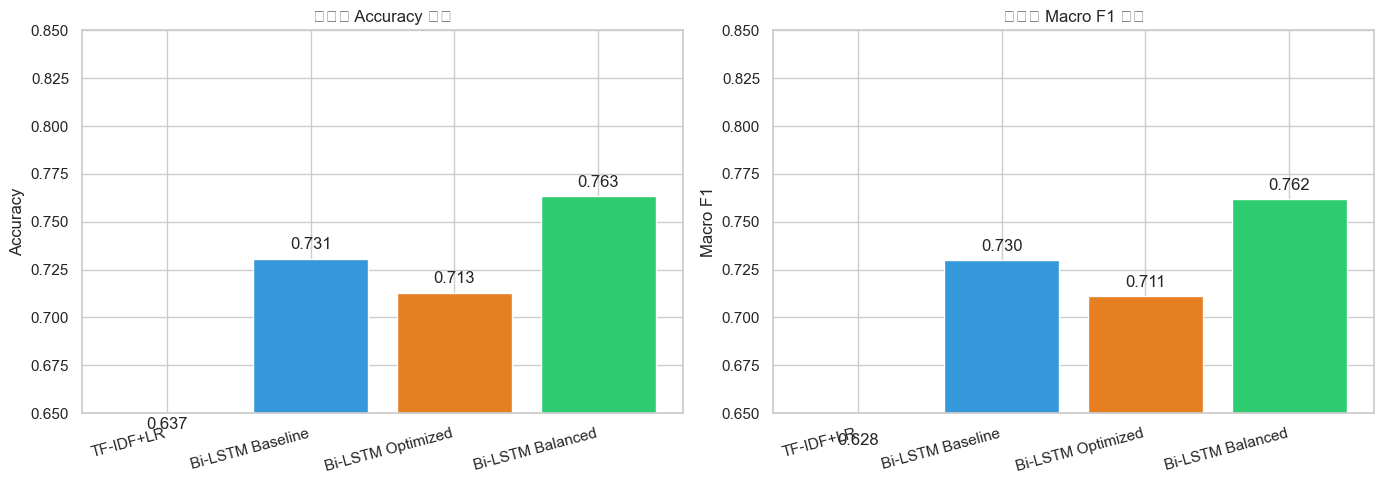

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = pd.DataFrame(rows)
colors = ["#95a5a6", "#3498db", "#e67e22", "#2ecc71"][: len(plot_df)]
x = range(len(plot_df))
axes[0].bar(x, plot_df["Test Acc"], color=colors)
axes[0].set_xticks(list(x), plot_df["模型"], rotation=15, ha="right")
axes[0].set_ylim(0.65, 0.85)
axes[0].set_title("测试集 Accuracy 对比")
axes[0].set_ylabel("Accuracy")
for i, v in enumerate(plot_df["Test Acc"]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center")

axes[1].bar(x, plot_df["Test F1"], color=colors)
axes[1].set_xticks(list(x), plot_df["模型"], rotation=15, ha="right")
axes[1].set_ylim(0.65, 0.85)
axes[1].set_title("测试集 Macro F1 对比")
axes[1].set_ylabel("Macro F1")
for i, v in enumerate(plot_df["Test F1"]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\137877197.py:18: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\137877197.py:18: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\137877197.py:18: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_17376\137877197.py:18: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) Arial.
  plt.tight_layout()
e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\IPython\core\pylabtools.py:170: Us

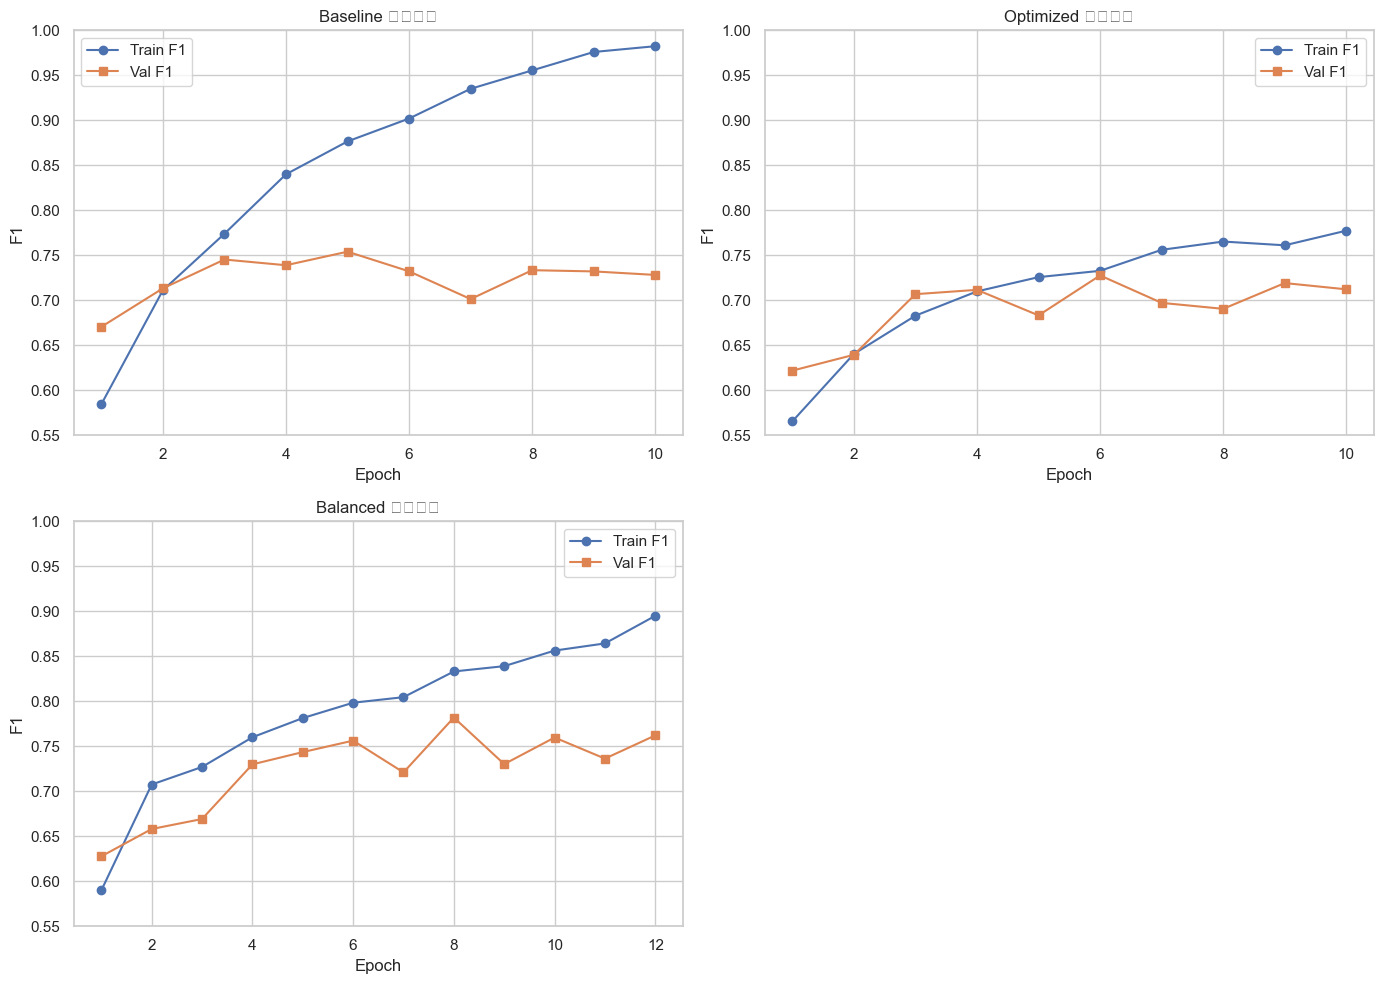

Balanced 模型在 epoch 8 取得最佳验证 F1 = 78.20%，测试 F1 = 76.18%。
Baseline 存在明显过拟合（训练 F1 接近 98%），Optimized 正则过强导致性能下降。


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
profiles = [("baseline", "Baseline"), ("optimized", "Optimized"), ("balanced", "Balanced")]

for ax, (name, title) in zip(axes.flat, profiles):
    hist = load_history(name)
    if hist is None:
        ax.set_title(f"{title}（无训练记录）")
        continue
    ax.plot(hist["epoch"], hist["train_f1"], marker="o", label="Train F1")
    ax.plot(hist["epoch"], hist["val_f1"], marker="s", label="Val F1")
    ax.set_title(f"{title} 训练曲线")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1")
    ax.legend()
    ax.set_ylim(0.55, 1.0)

axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

print("Balanced 模型在 epoch 8 取得最佳验证 F1 = 78.20%，测试 F1 = 76.18%。")
print("Baseline 存在明显过拟合（训练 F1 接近 98%），Optimized 正则过强导致性能下降。")

### 6.5 可视化分析

e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  fig.canvas.draw()
e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  fig.canvas.draw()
e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  fig.canvas.draw()
e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 28385 (\N{CJK UNIFIED IDEOGRAPH-6EE1}) missing from font(s) Arial.
  fig.canvas.draw()
e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) Arial.
  fig.canvas.draw()
e:\Apps\Anaconda_envs\envs\test4\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 30495 (\N{CJK UNIFI

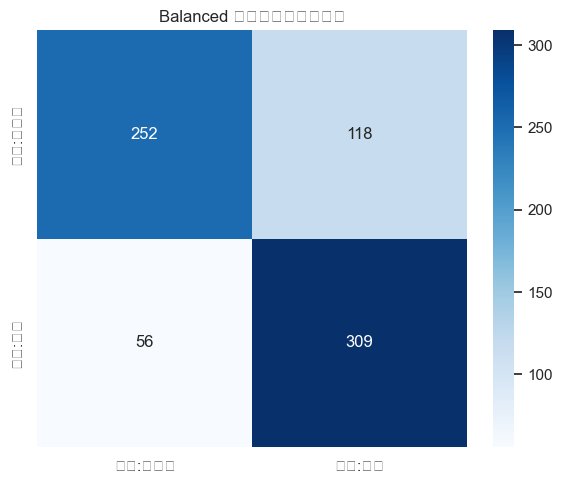

In [9]:
def report_to_confusion_matrix(report: dict, label_keys):
    supports = [int(report[k]["support"]) for k in label_keys]
    recalls = [report[k]["recall"] for k in label_keys]
    tp = [round(s * r) for s, r in zip(supports, recalls)]
    fn = [supports[i] - tp[i] for i in range(len(label_keys))]
    cm = [[tp[0], fn[0]], [fn[1], tp[1]]]
    return cm


balanced_report = load_test_result("balanced")["classification_report"]
cm = report_to_confusion_matrix(balanced_report, ["不满意(0)", "满意(1)"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["预测:不满意", "预测:满意"],
    yticklabels=["真实:不满意", "真实:满意"],
    ax=ax,
)
ax.set_title("Balanced 模型测试集混淆矩阵")
plt.tight_layout()
plt.show()

In [10]:
import torch
from torch.utils.data import DataLoader

from dataset import ReviewDataset, Vocab, collate_batch, load_csv
from model import BiLSTMSentimentClassifier

ckpt_dir = PROJECT_DIR / "checkpoints_balanced"
ckpt_path = ckpt_dir / "best_model.pt"
vocab_path = ckpt_dir / "vocab.pkl"

error_samples = []

if ckpt_path.exists() and vocab_path.exists():
    config = load_json(ckpt_dir / "config.json")
    vocab = Vocab.load(vocab_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = BiLSTMSentimentClassifier(
        vocab_size=len(vocab),
        embed_dim=config["embed_dim"],
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
        embed_dropout=config["embed_dropout"],
        pooling=config["pooling"],
    ).to(device)
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    test_loader = DataLoader(
        ReviewDataset(load_csv(DATA_DIR / "test.csv"), vocab, config["max_len"]),
        batch_size=64,
        shuffle=False,
        collate_fn=collate_batch,
    )

    test_reviews = test_df["review"].tolist()
    idx = 0
    with torch.no_grad():
        for input_ids, lengths, labels in test_loader:
            logits = model(input_ids.to(device), lengths.to(device))
            preds = torch.argmax(logits, dim=1).cpu().tolist()
            for i, (pred, label) in enumerate(zip(preds, labels.tolist())):
                if pred != label:
                    error_samples.append(
                        {
                            "真实标签": label,
                            "预测标签": pred,
                            "评论": test_reviews[idx + i][:150],
                        }
                    )
            idx += len(labels)

    error_df = pd.DataFrame(error_samples).head(8)
    print("表 2  Balanced 模型错误预测样例（前 8 条）")
    display(error_df)
else:
    print("未找到 best_model.pt，展示测试集中随机样例供参考：")
    display(test_df.sample(4, random_state=42)[["review", "sentiment"]].assign(
        review=lambda d: d["review"].str.slice(0, 120)
    ))

表 2  Balanced 模型错误预测样例（前 8 条）


,真实标签,预测标签,评论
0,0,1,美名其曰幕府对三国实际上幕府就是个npc你根本加入不了，只能进入三国阵营，玩法和率土差不多不...
1,0,1,游戏很好，但是有一点非常气人，在乱战模式中，一旦被打死所有分数都会消失，等级也会消失，但是等...
2,0,1,怎么没有复位键啊，我打排位一可是被撞墙上，卡到游戏结束，心态爆炸
3,1,0,都是反馈意见，请相信一个永久卡+季卡玩家的反馈，时长记录没开，最近版本更新后回归，人物昵称：...
4,1,0,这游戏如果不是腾讯出的话应该能有个7.5+的分数，内容很丰富，总体制作也是蛮精良的。腾讯的氪...
5,0,1,删档测试玩家玩到现在正式服上线，从内心5星掉到3星。运营上，测试的时候身边经常还能刷橙色，当...
6,0,1,网速很好，一切正常。一点进去就是请求超时，误点进一个剧本退也退不出，还不能关麦，什么***。
7,0,1,反正这游戏给我的感觉就是手机版的流放之路。玩了一天，没感觉到有什么bug，但是地图加载太慢了...


**错误分析**：

- 部分评论情感表达隐晦（如反讽、先扬后抑），模型容易误判
- 长评论中前后情感不一致时，单一全局标签难以准确建模
- 游戏领域专有名词较多，随机初始化的 Embedding 对 OOV 词处理能力有限

---

## 七、总结与展望

### 7.1 工作总结

本项目完成了 TapTap 中文游戏评论情感分类的完整流程：数据划分 → 预处理 → Bi-LSTM 建模 → 多组对比实验 → 结果分析。最终 **Balanced** 模型测试集准确率为 **76.33%**，Macro F1 为 **76.18%**，优于传统 TF-IDF 基线与原始 Bi-LSTM Baseline。

### 7.2 主要结论

1. Bi-LSTM 能有效捕获中文评论的上下文语义，优于 TF-IDF 传统方法
2. 单纯增大训练轮次会导致过拟合，需配合早停与正则化
3. 强正则化（Optimized）虽缓解过拟合，但会损失模型容量，测试性能反而下降
4. 折中方案（Balanced）在容量、正则与 attention 池化之间取得最佳平衡

### 7.3 未来改进方向

- 引入中文预训练词向量或 BERT 预训练模型
- 使用 Optuna 等工具进行系统化超参数搜索
- 增加反讽、网络用语等难例的数据增强
- 开发在线预测接口，支持单条评论实时情感分析